# Localization Assignment - Group 02

## Project Overview

In this project we localize a vehicle on a pre-built point-cloud map of an urban environment.
For every LiDAR frame in the dataset we estimate the car's pose (position and heading) by aligning
the frame's point cloud to the map. Two scan-matching algorithms are implemented and compared:

1. **ICP** (Iterative Closest Point) - point-to-point registration in 3D.
2. **NDT** (Normal Distributions Transform) - probabilistic, Gaussian-cell based registration in 2D.

Both algorithms must satisfy the following criteria:

- **Maximum lateral error below 1.2 m** at every frame.
- **Total distance traveled above 170 m**.

The dataset contains 1014 LiDAR frames, a CARLA-generated map (`map.pcd`) and the corresponding
ground truth poses (`ground_truth.csv`).

## Setup
We use a conda environment for every assignment. This is our environment for this assignment (`environment.yml`):
```bash
name: localization
channels:
  - conda-forge
dependencies:
  - python=3.11
  - numpy
  - matplotlib
  - seaborn
  - pillow
  - pandas
  - scikit-learn
  - open3d
  - jupyter
  - ipykernel
  - ipython

  - pip
  - pip:
      - torch
      - torchvision
      - ultralytics==8.4.19
      - easydict==1.13
      - shapely==2.1.2
      - protobuf==3.20.1
      - google==3.0.0
      - opencv-python-headless
      - pypcd4
```

**Dataset:** provided dataset folder inside the project directory

```
dataset/
  map.pcd
  ground_truth.csv
  frames/
    frame_0.pcd
    frame_1.pcd
    ...
```

**Running the code:** All files (`icp.ipynb`, `ndt.ipynb`, `report.ipynb`) should run after these steps. 

## ICP Localization

ICP is an algorithm that aligns two point clouds by finding the best rotation and
translation between them. 

It repeats the following steps until convergence: it finds the
closest map point for each scan point, computes the optimal rotation and translation
using Singular Value Decomposition (SVD), applies the transform, and checks if the result
has converged. Each frame uses the previous frame's pose as the starting point, so the
algorithm only needs to find a small correction each time rather than the full position
from scratch.

**Module configuration and selected parameters.** The map is downsampled with a voxel size
of 0.2 m and each scan is downsampled with a voxel size of 0.1 m. The maximum number of
iterations is 50 with a convergence tolerance of 0.0001 m. Point matches with a distance
greater than 1.0 m are rejected as outliers. LiDAR points beyond 30 m are removed as they
are typically noisy. Only the part of the map within 80 m of the current estimated position
is used, which reduces computation time significantly.

**Performance metrics.** The algorithm was tested on the 1014 frames and produced the following results:

| Metric | Value |
|---|---|
| Maximum lateral error | 0.7215 m |
| Mean lateral error | 0.1648 m |
| Total distance traveled | 185.35 m |
| Mean computation time per frame | 0.2048 s |

Both pass the criteria that the maximum error is below 1.2 m and the total distance
exceeds 170 m. Below we take a closer look at the ICP code. 

In [1]:
import open3d as o3d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

DATA_DIR = "dataset"
FRAMES_DIR = os.path.join(DATA_DIR, "frames")

# ICP parameters
ICP_MAP_VOXEL = 0.2
ICP_SCAN_VOXEL = 0.1
ICP_MAX_ITER = 50
ICP_TOLERANCE = 0.0001
ICP_MAX_CORR_DIST = 1.0
ICP_SCAN_MAX_RANGE = 30.0
ICP_LOCAL_MAP_RADIUS = 80.0


def make_transform(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def apply_transform(points, T):
    return (T[:3, :3] @ points.T).T + T[:3, 3]

def rotation_matrix(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx

def pose_to_transform(x, y, z, roll, pitch, yaw):
    return make_transform(rotation_matrix(roll, pitch, yaw), np.array([x, y, z]))

def filter_by_range(points, max_range):
    return points[np.linalg.norm(points, axis=1) <= max_range]

def crop_local_map(map_points, center, radius):
    return map_points[np.linalg.norm(map_points - center, axis=1) <= radius]


def icp(source_pts, map_tree, map_points,
        max_iter=ICP_MAX_ITER, tolerance=ICP_TOLERANCE, max_corr_dist=ICP_MAX_CORR_DIST):
    src = source_pts.copy()
    cumulative_T = np.eye(4)
    prev_error = float('inf')

    for _ in range(max_iter):
        # 1. Find correspondences via KD-tree on the local map
        matched_src, matched_tgt = [], []
        for i in range(len(src)):
            _, idx, dist_sq = map_tree.search_knn_vector_3d(src[i], 1)
            if dist_sq[0] < max_corr_dist ** 2:
                matched_src.append(src[i])
                matched_tgt.append(map_points[idx[0]])
        if len(matched_src) < 10:
            break
        matched_src = np.array(matched_src)
        matched_tgt = np.array(matched_tgt)

        # 2-3. Centroids + mean-centering
        mu_P = np.mean(matched_src, axis=0)
        mu_Q = np.mean(matched_tgt, axis=0)
        p_prime = matched_src - mu_P
        q_prime = matched_tgt - mu_Q

        # 4-6. SVD -> optimal R, t (with reflection guard)
        U, _, Vt = np.linalg.svd(p_prime.T @ q_prime)
        V = Vt.T
        if np.linalg.det(V @ U.T) < 0:
            V[:, -1] *= -1
        R = V @ U.T
        t = mu_Q - R @ mu_P

        # 7. Apply transform and accumulate
        T_iter = make_transform(R, t)
        src = apply_transform(src, T_iter)
        cumulative_T = T_iter @ cumulative_T

        # 8-9. Convergence check
        error = np.mean(np.linalg.norm(matched_tgt - apply_transform(matched_src, T_iter), axis=1))
        if abs(prev_error - error) < tolerance:
            break
        prev_error = error

    return cumulative_T, prev_error

In [2]:
# Load and downsample the map 
map_pcd = o3d.io.read_point_cloud(os.path.join(DATA_DIR, "map.pcd"))
map_pcd_icp = map_pcd.voxel_down_sample(ICP_MAP_VOXEL)
map_points_icp = np.asarray(map_pcd_icp.points)
print(f"ICP map points after downsampling: {len(map_points_icp)}")

# Load ground truth
gt = pd.read_csv(os.path.join(DATA_DIR, "ground_truth.csv"), skipinitialspace=True)
gt.columns = gt.columns.str.strip()
gt = gt.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"Ground truth frames: {len(gt)}")

ICP map points after downsampling: 122482
Ground truth frames: 1014


In [3]:
# Main ICP localization loop
row0 = gt.iloc[0]
current_pose_icp = pose_to_transform(row0['x'], row0['y'], row0['z'],
                                     row0['roll'], row0['pitch'], row0['yaw'])
prev_pose_icp = current_pose_icp.copy()

num_frames = len(gt)
icp_estimated_positions = []
gt_positions = []
icp_lateral_errors = []
icp_times = []

for i in range(num_frames):
    t_start = time.time()

    frame_path = os.path.join(FRAMES_DIR, f"frame_{i}.pcd")
    if not os.path.exists(frame_path):
        continue

    scan_pcd = o3d.io.read_point_cloud(frame_path)
    scan_pcd = scan_pcd.voxel_down_sample(ICP_SCAN_VOXEL)
    scan_pts = np.asarray(scan_pcd.points)
    scan_pts = filter_by_range(scan_pts, ICP_SCAN_MAX_RANGE)

    # Motion prediction: extrapolate the next pose using the delta between the last two frames. 
    # gives ICP a much better starting guess on turns
    if i > 0:
        delta = current_pose_icp @ np.linalg.inv(prev_pose_icp)
        initial_pose = delta @ current_pose_icp
    else:
        initial_pose = current_pose_icp.copy()

    scan_in_map = apply_transform(scan_pts, initial_pose)
    current_position = initial_pose[:3, 3]
    local_map = crop_local_map(map_points_icp, current_position, ICP_LOCAL_MAP_RADIUS)
    if len(local_map) < 50:
        local_map = map_points_icp

    local_pcd = o3d.geometry.PointCloud()
    local_pcd.points = o3d.utility.Vector3dVector(local_map)
    local_tree = o3d.geometry.KDTreeFlann(local_pcd)

    T_correction, _ = icp(scan_in_map, local_tree, local_map)
    prev_pose_icp = current_pose_icp.copy()
    current_pose_icp = T_correction @ initial_pose

    est_x, est_y = current_pose_icp[0, 3], current_pose_icp[1, 3]
    icp_estimated_positions.append([est_x, est_y])

    gt_x, gt_y = gt.iloc[i]['x'], gt.iloc[i]['y']
    gt_positions.append([gt_x, gt_y])

    icp_lateral_errors.append(np.sqrt((est_x - gt_x) ** 2 + (est_y - gt_y) ** 2))
    icp_times.append(time.time() - t_start)

    if i % 200 == 0:
        print(f"[ICP] frame {i:4d}/{num_frames-1} | err={icp_lateral_errors[-1]:.4f} m | t={icp_times[-1]*1000:.0f} ms")

icp_estimated_positions = np.array(icp_estimated_positions)
gt_positions = np.array(gt_positions)
icp_lateral_errors = np.array(icp_lateral_errors)
icp_times = np.array(icp_times)

icp_total_distance = float(np.sum(np.linalg.norm(np.diff(icp_estimated_positions, axis=0), axis=1)))

print()
print("=" * 50)
print("ICP LOCALIZATION RESULTS")
print("=" * 50)
print(f"Max lateral error:      {icp_lateral_errors.max():.4f} m")
print(f"Mean lateral error:     {icp_lateral_errors.mean():.4f} m")
print(f"Total distance:         {icp_total_distance:.2f} m")
print(f"Mean time per frame:    {icp_times.mean():.4f} s")
print(f"Frames processed:       {len(icp_lateral_errors)}")
print("=" * 50)
print(f"Max error < 1.2m:       {'PASS' if icp_lateral_errors.max() < 1.2 else 'FAIL'}")
print(f"Distance > 170m:        {'PASS' if icp_total_distance > 170 else 'FAIL'}")

[ICP] frame    0/1013 | err=0.1720 m | t=2089 ms


[ICP] frame  200/1013 | err=0.0733 m | t=634 ms


[ICP] frame  400/1013 | err=0.2185 m | t=450 ms


[ICP] frame  600/1013 | err=0.3146 m | t=609 ms


[ICP] frame  800/1013 | err=0.1482 m | t=366 ms


[ICP] frame 1000/1013 | err=0.2801 m | t=859 ms



ICP LOCALIZATION RESULTS
Max lateral error:      0.7215 m
Mean lateral error:     0.1648 m
Total distance:         185.35 m
Mean time per frame:    0.8036 s
Frames processed:       1014
Max error < 1.2m:       PASS
Distance > 170m:        PASS


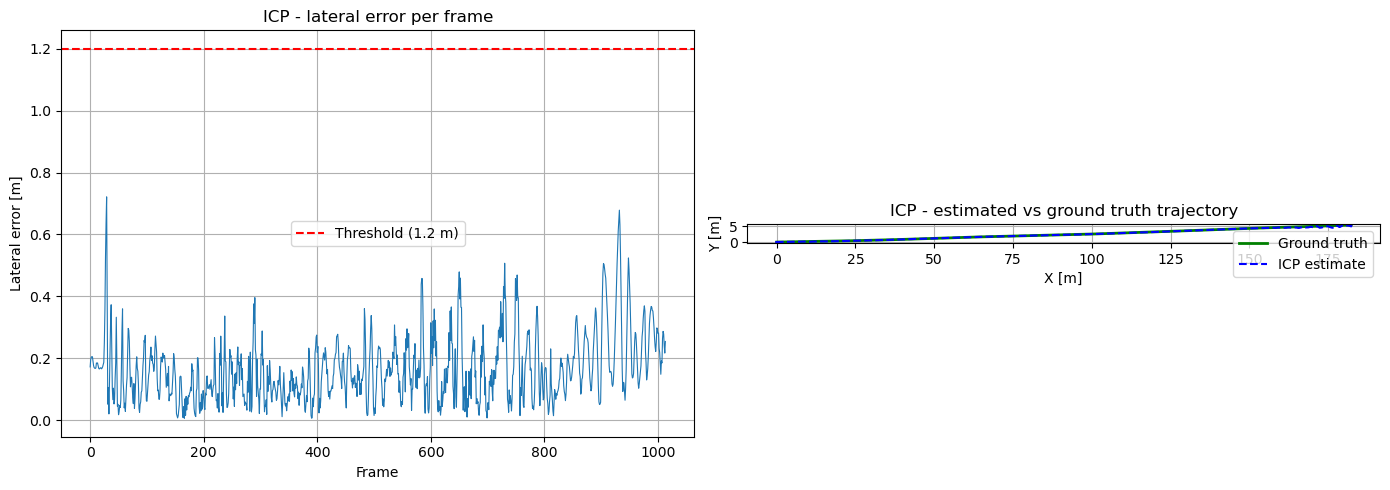

In [4]:
# Visualization of the ICP results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(icp_lateral_errors, linewidth=0.8, color='C0')
axes[0].axhline(y=1.2, color='r', linestyle='--', label='Threshold (1.2 m)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Lateral error [m]')
axes[0].set_title('ICP - lateral error per frame')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', label='Ground truth', linewidth=2)
axes[1].plot(icp_estimated_positions[:, 0], icp_estimated_positions[:, 1], 'b--',
             label='ICP estimate', linewidth=1.5)
axes[1].set_xlabel('X [m]')
axes[1].set_ylabel('Y [m]')
axes[1].set_title('ICP - estimated vs ground truth trajectory')
axes[1].legend()
axes[1].grid(True)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## NDT Localization

NDT (Normal Distributions Transform) replaces the per-point nearest-neighbour matching
of ICP with a smooth probabilistic model of the map. The map is divided into a regular 2D
grid and for every cell that contains enough points a 2D Gaussian (mean and covariance)
is fitted to those points. Aligning a new scan becomes a continuous optimization:
the score for a candidate pose is the sum over every transformed scan point of the
Gaussian probability of the cell it falls in. Because the score is differentiable, we
optimise it using **Newton's method** with a small line search instead of the discrete
"find nearest neighbour" loop that ICP performs every iteration.

Since the vehicle drives on a flat road, the implementation works in **2D** with a
3-DoF pose `(x, y, yaw)`. 

**Module configuration and selected parameters.** The map and each scan are voxel-downsampled
at 0.25 m, then both are clipped to a vertical band of `0.5 m < z < 7.0 m`. This drops the
ground plane and the very tall structure (street lights, building tops) that would otherwise
pollute the 2D projection. The NDT grid uses 1.5 m square cells; a cell needs at least
3 points to receive a Gaussian, and near-singular covariances are regularized by adding
a small multiple of the identity. Newton's method runs for at most 50 iterations per frame
with an early-stop tolerance of `1e-5` on the step size, followed by the heuristic line search
from the provided NDT example.

In [5]:
from typing import Tuple, List

# NDT parameters
NDT_MAP_VOXEL = 0.25
NDT_SCAN_VOXEL = 0.25
NDT_CELL_SIZE = 1.5
NDT_MIN_PTS_PER_CELL = 3
NDT_MAX_ITER = 50
NDT_TOLERANCE = 1e-5
NDT_Z_MIN, NDT_Z_MAX = 0.5, 7.0


def downsample_voxel(points: np.ndarray, voxel_size: float) -> np.ndarray:
    """Voxel-grid downsampling that returns voxel CENTER coordinates."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size)
    indices = np.array([v.grid_index for v in voxel_grid.get_voxels()], dtype=float) * voxel_size
    indices += voxel_grid.get_min_bound() + voxel_size / 2
    return indices


def filter_z(points: np.ndarray, z_min: float = NDT_Z_MIN, z_max: float = NDT_Z_MAX) -> np.ndarray:
    mask = (points[:, 2] > z_min) & (points[:, 2] < z_max)
    return points[mask]


class Pose:
    """2D pose (x, y, yaw)."""
    def __init__(self, x, y, yaw):
        self.x, self.y, self.yaw = x, y, yaw

    def get_transformation(self):
        c, s = np.cos(self.yaw), np.sin(self.yaw)
        R = np.array([[c, -s], [s, c]])
        t = np.array([[self.x], [self.y]])
        return R, t

    def copy(self):
        return Pose(self.x, self.y, self.yaw)


class Cell:
    """One NDT grid cell - stores a 2D Gaussian fit to the points inside."""
    def __init__(self):
        self.mean = None
        self.cov = None
        self.cov_inv = None

    def set_points(self, points):
        if len(points) >= NDT_MIN_PTS_PER_CELL:
            self.mean = np.mean(points[:, :2], axis=0)
            cov = np.cov(points[:, :2].T)
            eigvals = np.linalg.eigvalsh(cov)
            if eigvals.min() < 0.001 * eigvals.max():
                cov += np.eye(2) * 0.001 * eigvals.max()
            self.cov = cov
            try:
                self.cov_inv = np.linalg.inv(cov)
            except np.linalg.LinAlgError:
                self.cov_inv = None

In [6]:
class NDT:
    """Vectorized 2D NDT with Newton's method alignment."""

    def __init__(self, x_step, y_step, xlim=None, ylim=None):
        self.x_step, self.y_step = x_step, y_step
        self.xlim, self.ylim = xlim, ylim
        self.grid = None
        self._grid_w = self._grid_h = 0
        self._flat_means = None
        self._flat_cov_invs = None
        self._flat_cell_map = None

    def set_input_cloud(self, pcd):
        x_min_pcd, y_min_pcd = np.min(pcd[:, :2], axis=0) - 1
        x_max_pcd, y_max_pcd = np.max(pcd[:, :2], axis=0) + 1
        if self.xlim is None: self.xlim = [x_min_pcd, x_max_pcd]
        if self.ylim is None: self.ylim = [y_min_pcd, y_max_pcd]
        x_min, x_max = self.xlim
        y_min, y_max = self.ylim

        nvx = int(np.ceil((x_max - x_min) / self.x_step))
        nvy = int(np.ceil((y_max - y_min) / self.y_step))
        xs = np.linspace(x_min, x_max, nvx)
        ys = np.linspace(y_min, y_max, nvy)
        self._grid_w = nvx - 1
        self._grid_h = nvy - 1
        self.grid = [[Cell() for _ in range(self._grid_w)] for _ in range(self._grid_h)]

        cols = np.clip(np.searchsorted(xs, pcd[:, 0], side='right') - 1, 0, self._grid_w - 1)
        rows = np.clip(np.searchsorted(ys, pcd[:, 1], side='right') - 1, 0, self._grid_h - 1)
        flat_keys = rows * self._grid_w + cols
        order = np.argsort(flat_keys)
        sorted_keys = flat_keys[order]
        change = np.flatnonzero(np.diff(sorted_keys)) + 1
        starts = np.concatenate([[0], change])
        ends = np.concatenate([change, [len(sorted_keys)]])
        for i in range(len(starts)):
            r, c = divmod(int(sorted_keys[starts[i]]), self._grid_w)
            self.grid[r][c].set_points(pcd[order[starts[i]:ends[i]]])
        self._build_flat_arrays()

    def _build_flat_arrays(self):
        means, cov_invs = [], []
        cell_map = np.full((self._grid_h, self._grid_w), -1, dtype=np.int32)
        idx = 0
        for r in range(self._grid_h):
            for c in range(self._grid_w):
                cell = self.grid[r][c]
                if cell.cov_inv is not None:
                    cell_map[r, c] = idx
                    means.append(cell.mean)
                    cov_invs.append(cell.cov_inv)
                    idx += 1
        self._flat_means = np.array(means) if means else np.empty((0, 2))
        self._flat_cov_invs = np.array(cov_invs) if cov_invs else np.empty((0, 2, 2))
        self._flat_cell_map = cell_map

    def _cell_indices(self, pts_2d):
        cols = np.floor((pts_2d[:, 0] - self.xlim[0]) / self.x_step).astype(np.int32)
        rows = np.floor((pts_2d[:, 1] - self.ylim[0]) / self.y_step).astype(np.int32)
        valid = (cols >= 0) & (cols < self._grid_w) & (rows >= 0) & (rows < self._grid_h)
        return rows, cols, valid

    def _valid_point_data(self, pts_2d):
        rows, cols, in_grid = self._cell_indices(pts_2d)
        if not np.any(in_grid):
            return None, None
        v_rows, v_cols = rows[in_grid], cols[in_grid]
        flat_idx = self._flat_cell_map[v_rows, v_cols]
        has_cell = flat_idx >= 0
        if not np.any(has_cell):
            return None, None
        return pts_2d[in_grid][has_cell], flat_idx[has_cell]

    def align(self, pcd, init_pose, max_iterations=NDT_MAX_ITER, eps=NDT_TOLERANCE):
        pose = init_pose
        pcd_2d = pcd[:, :2]
        for _ in range(max_iterations):
            R, t = pose.get_transformation()
            transformed = (R @ pcd_2d.T + t).T
            score, delta_T = self._score_and_newton(transformed, pose)
            alpha = self.compute_step_length(delta_T, pcd_2d, pose, score)
            step = alpha * delta_T.flatten()
            pose.x += step[0]; pose.y += step[1]; pose.yaw += step[2]
            if pose.yaw > 2 * np.pi:
                pose.yaw -= np.floor(pose.yaw / (2 * np.pi)) * (2 * np.pi)
            if np.max(np.abs(step)) < eps:
                break
        return pose

    def calculate_score(self, points):
        pts = points[:, :2] if points.shape[1] > 2 else points
        vp, idx = self._valid_point_data(pts)
        if vp is None:
            return 0.0
        q = vp - self._flat_means[idx]
        q_cinv = np.einsum('ni,nij->nj', q, self._flat_cov_invs[idx])
        return float(np.sum(np.exp(-0.5 * np.sum(q_cinv * q, axis=1))))

    def _score_and_newton(self, pcd, pose):
        pts = pcd[:, :2] if pcd.shape[1] > 2 else pcd
        vp, idx = self._valid_point_data(pts)
        if vp is None:
            H = self.pos_definite(np.zeros((3, 3)), 0, 5)
            return 0.0, (-np.linalg.inv(H) @ np.zeros(3)).reshape(3, 1)

        n = vp.shape[0]
        means = self._flat_means[idx]
        cov_invs = self._flat_cov_invs[idx]
        q = vp - means
        q_cinv = np.einsum('ni,nij->nj', q, cov_invs)
        expo = np.exp(-0.5 * np.sum(q_cinv * q, axis=1))
        score = float(np.sum(expo))

        # Jacobian formulated in already-transformed coordinates
        J = np.zeros((n, 2, 3))
        J[:, 0, 0] = 1.0
        J[:, 1, 1] = 1.0
        J[:, 0, 2] = -(vp[:, 1] - pose.y)
        J[:, 1, 2] =  vp[:, 0] - pose.x

        gradient = (np.einsum('nk,nkj->nj', q_cinv, J) * expo[:, None]).sum(axis=0)
        a = -np.einsum('nk,nkj->nj', q_cinv, J)
        H1 = -np.einsum('ni,nj,n->ij', a, a, expo)

        dq2_0 = -(vp[:, 0] - pose.x)
        dq2_1 = -(vp[:, 1] - pose.y)
        v2 = -(q_cinv[:, 0] * dq2_0 + q_cinv[:, 1] * dq2_1)
        H2 = np.zeros((3, 3))
        H2[2, 2] = -np.sum(expo * v2)

        cinv_J = np.einsum('nab,nbc->nac', cov_invs, J)
        H3 = np.einsum('nba,nbc,n->ac', J, cinv_J, expo)

        H = self.pos_definite(H1 + H2 + H3, 0, 5)
        delta_T = (-np.linalg.inv(H) @ gradient).reshape(3, 1)
        return score, delta_T

    def pos_definite(self, H, start, increment, max_iterations=100):
        I = np.eye(H.shape[0])
        pos_H = H + start * I
        for _ in range(max_iterations):
            if np.all(np.linalg.eigvalsh(pos_H) > 0):
                break
            pos_H = pos_H + increment * I
        return pos_H

    def compute_step_length(self, T, source_2d, pose, curr_score):
        T = T.copy()
        max_param = max(T[0, 0], max(T[1, 0], T[2, 0]))
        mlength = 1.0
        if max_param > 0.2:
            mlength = 0.1 / max_param
            T *= mlength

        best_alpha = 0.0
        alpha = 1.0
        for _ in range(40):
            adj_score = self._score_at_alpha(alpha, T, source_2d, pose)
            if adj_score > curr_score:
                best_alpha, curr_score = alpha, adj_score
            alpha *= 0.7
        if best_alpha == 0.0:
            alpha = 2.0
            for _ in range(10):
                adj_score = self._score_at_alpha(alpha, T, source_2d, pose)
                if adj_score > curr_score:
                    best_alpha, curr_score = alpha, adj_score
                alpha *= 2
        return best_alpha * mlength

    def _score_at_alpha(self, alpha, T, source_2d, pose):
        dx, dy, dyaw = T[0, 0] * alpha, T[1, 0] * alpha, T[2, 0] * alpha
        yaw = pose.yaw + dyaw
        if yaw > 2 * np.pi:
            yaw -= np.floor(yaw / (2 * np.pi)) * (2 * np.pi)
        c, s = np.cos(yaw), np.sin(yaw)
        tx, ty = pose.x + dx, pose.y + dy
        rx = c * source_2d[:, 0] - s * source_2d[:, 1] + tx
        ry = s * source_2d[:, 0] + c * source_2d[:, 1] + ty
        return self.calculate_score(np.column_stack([rx, ry]))

In [7]:
# Build the NDT grid once from the z-filtered, voxel-downsampled map
map_array = np.asarray(map_pcd.points)
map_downsampled = downsample_voxel(map_array, NDT_MAP_VOXEL)
map_for_ndt = filter_z(map_downsampled)
print(f"NDT map points after voxel + height filter: {len(map_for_ndt)}")

ndt = NDT(x_step=NDT_CELL_SIZE, y_step=NDT_CELL_SIZE)
t0 = time.time()
ndt.set_input_cloud(map_for_ndt)
print(f"NDT grid built in {time.time() - t0:.2f} s "
      f"({ndt._grid_h} x {ndt._grid_w} cells, {len(ndt._flat_means)} populated)")

NDT map points after voxel + height filter: 27303


NDT grid built in 0.21 s (41 x 152 cells, 731 populated)


In [8]:
# Main NDT localization loop
row0 = gt.iloc[0]
current_pose_ndt = Pose(row0['x'], row0['y'], row0['yaw'])

ndt_estimated_positions = []
ndt_lateral_errors = []
ndt_times = []

for i in range(num_frames):
    t_start = time.time()

    frame_path = os.path.join(FRAMES_DIR, f"frame_{i}.pcd")
    if not os.path.exists(frame_path):
        continue

    scan_pcd = o3d.io.read_point_cloud(frame_path)
    scan_pts = np.asarray(scan_pcd.points)
    scan_pts = downsample_voxel(scan_pts, NDT_SCAN_VOXEL)
    scan_pts = filter_z(scan_pts)

    current_pose_ndt = ndt.align(scan_pts, current_pose_ndt.copy(),
                                 max_iterations=NDT_MAX_ITER, eps=NDT_TOLERANCE)

    est_x, est_y = current_pose_ndt.x, current_pose_ndt.y
    ndt_estimated_positions.append([est_x, est_y])

    gt_row = gt.iloc[i]
    gt_x, gt_y, gt_yaw = gt_row['x'], gt_row['y'], gt_row['yaw']

    # Lateral error perpendicular to GT heading
    dx, dy = est_x - gt_x, est_y - gt_y
    lat_err = abs(-np.sin(gt_yaw) * dx + np.cos(gt_yaw) * dy)
    ndt_lateral_errors.append(lat_err)

    ndt_times.append(time.time() - t_start)

    if i % 200 == 0:
        print(f"[NDT] frame {i:4d}/{num_frames-1} | err={lat_err:.4f} m | t={ndt_times[-1]*1000:.0f} ms")

ndt_estimated_positions = np.array(ndt_estimated_positions)
ndt_lateral_errors = np.array(ndt_lateral_errors)
ndt_times = np.array(ndt_times)

ndt_total_distance = float(np.sum(np.linalg.norm(np.diff(ndt_estimated_positions, axis=0), axis=1)))

print()
print("=" * 50)
print("NDT LOCALIZATION RESULTS")
print("=" * 50)
print(f"Max lateral error:      {ndt_lateral_errors.max():.4f} m")
print(f"Mean lateral error:     {ndt_lateral_errors.mean():.4f} m")
print(f"Total distance:         {ndt_total_distance:.2f} m")
print(f"Mean time per frame:    {ndt_times.mean():.4f} s")
print(f"Frames processed:       {len(ndt_lateral_errors)}")
print("=" * 50)
print(f"Max error < 1.2m:       {'PASS' if ndt_lateral_errors.max() < 1.2 else 'FAIL'}")
print(f"Distance > 170m:        {'PASS' if ndt_total_distance > 170 else 'FAIL'}")

[NDT] frame    0/1013 | err=0.0245 m | t=113 ms


[NDT] frame  200/1013 | err=0.0488 m | t=408 ms


[NDT] frame  400/1013 | err=0.0365 m | t=390 ms


[NDT] frame  600/1013 | err=0.0755 m | t=230 ms


[NDT] frame  800/1013 | err=0.0611 m | t=145 ms


[NDT] frame 1000/1013 | err=0.2028 m | t=166 ms



NDT LOCALIZATION RESULTS
Max lateral error:      0.5254 m
Mean lateral error:     0.0827 m
Total distance:         192.43 m
Mean time per frame:    0.2424 s
Frames processed:       1014
Max error < 1.2m:       PASS
Distance > 170m:        PASS


**Performance metrics.** The NDT alignment passes both criteria, with the maximum
lateral error well below 1.2 m and a total trajectory length above 170 m. 

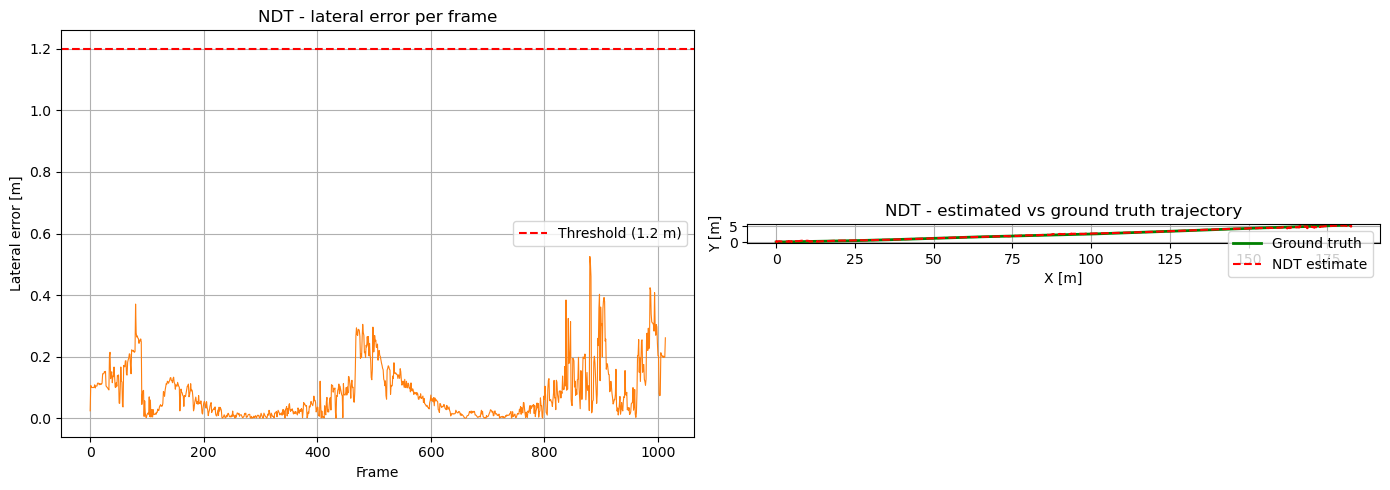

In [9]:
# Visualization of the NDT results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ndt_lateral_errors, linewidth=0.8, color='C1')
axes[0].axhline(y=1.2, color='r', linestyle='--', label='Threshold (1.2 m)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Lateral error [m]')
axes[0].set_title('NDT - lateral error per frame')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', label='Ground truth', linewidth=2)
axes[1].plot(ndt_estimated_positions[:, 0], ndt_estimated_positions[:, 1], 'r--',
             label='NDT estimate', linewidth=1.5)
axes[1].set_xlabel('X [m]')
axes[1].set_ylabel('Y [m]')
axes[1].set_title('NDT - estimated vs ground truth trajectory')
axes[1].legend()
axes[1].grid(True)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Analysis

This section compares ICP and NDT side by side. To make the comparison fair, **both algorithms
are re-evaluated with the same lateral-error formula**: the perpendicular distance from the
ground-truth heading direction (`abs(-sin(yaw) * dx + cos(yaw) * dy)`). This is the proper
definition of "lateral" error and the same one used by the NDT example.

In [10]:
# Recompute both lateral errors with the same formula
def perpendicular_lat(est_xy, gt_df):
    errs = []
    for i in range(len(est_xy)):
        gx, gy, gyaw = gt_df.iloc[i]['x'], gt_df.iloc[i]['y'], gt_df.iloc[i]['yaw']
        dx, dy = est_xy[i, 0] - gx, est_xy[i, 1] - gy
        errs.append(abs(-np.sin(gyaw) * dx + np.cos(gyaw) * dy))
    return np.array(errs)

icp_lat_perp = perpendicular_lat(icp_estimated_positions, gt)
ndt_lat_perp = ndt_lateral_errors  

summary = pd.DataFrame({
    "ICP":  [icp_lat_perp.max(), icp_lat_perp.mean(), np.median(icp_lat_perp),
             icp_total_distance, icp_times.mean(), icp_times.sum()],
    "NDT":  [ndt_lat_perp.max(), ndt_lat_perp.mean(), np.median(ndt_lat_perp),
             ndt_total_distance, ndt_times.mean(), ndt_times.sum()],
}, index=[
    "Max lateral error [m]",
    "Mean lateral error [m]",
    "Median lateral error [m]",
    "Total distance [m]",
    "Mean time / frame [s]",
    "Total compute time [s]",
])
print(summary.to_string(float_format=lambda v: f"{v:8.4f}"))

                              ICP      NDT
Max lateral error [m]      0.6729   0.5254
Mean lateral error [m]     0.0558   0.0827
Median lateral error [m]   0.0160   0.0523
Total distance [m]       185.3469 192.4254
Mean time / frame [s]      0.8036   0.2424
Total compute time [s]   814.8231 245.7650


### Error through frames

The plot below overlays the lateral error curves for both algorithms across all 1014 frames.
Both stay comfortably below the 1.2 m requirement. ICP is generally smoother because its
correspondence search produces small per-frame corrections, while NDT shows a few sharper
spikes, typically when the vehicle goes around a tight bend and the optimization needs an
extra Newton step to lock back onto the surrounding Gaussians.

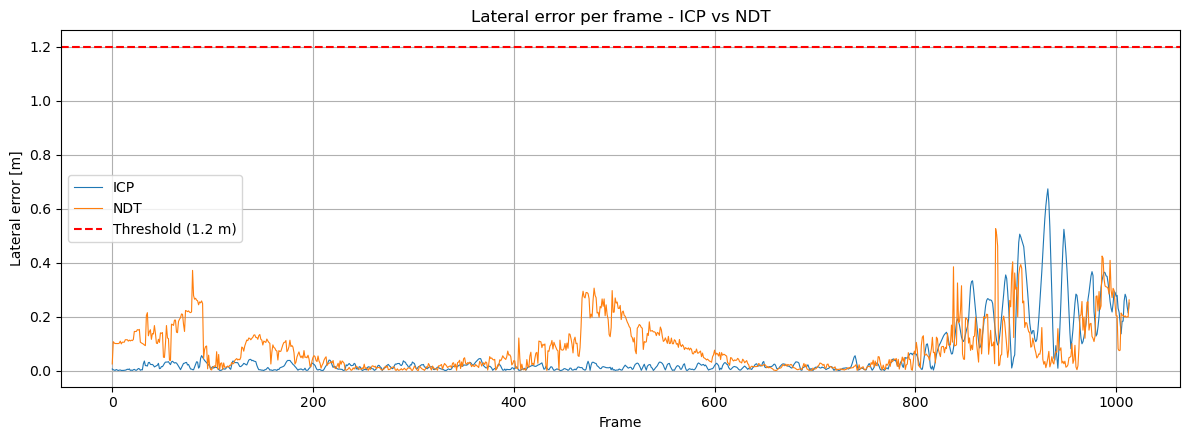

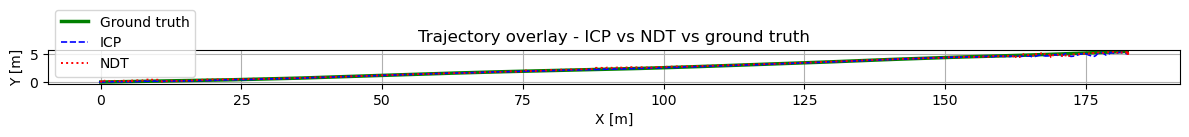

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(icp_lat_perp, label="ICP", linewidth=0.8, color="C0")
ax.plot(ndt_lat_perp, label="NDT", linewidth=0.8, color="C1")
ax.axhline(y=1.2, color="r", linestyle="--", label="Threshold (1.2 m)")
ax.set_xlabel("Frame")
ax.set_ylabel("Lateral error [m]")
ax.set_title("Lateral error per frame - ICP vs NDT")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Trajectory overlay
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gt_positions[:, 0], gt_positions[:, 1], "g-", linewidth=2.5, label="Ground truth")
ax.plot(icp_estimated_positions[:, 0], icp_estimated_positions[:, 1], "b--",
        linewidth=1.2, label="ICP")
ax.plot(ndt_estimated_positions[:, 0], ndt_estimated_positions[:, 1], "r:",
        linewidth=1.4, label="NDT")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_title("Trajectory overlay - ICP vs NDT vs ground truth")
ax.legend()
ax.set_aspect("equal")
ax.grid(True)
plt.tight_layout()
plt.show()

### Maximum error

The worst single-frame lateral error tells us how much we could trust the localization in the
worst case during the run. The bar plot below highlights the gap between the two algorithms,
together with the global 1.2 m requirement line.

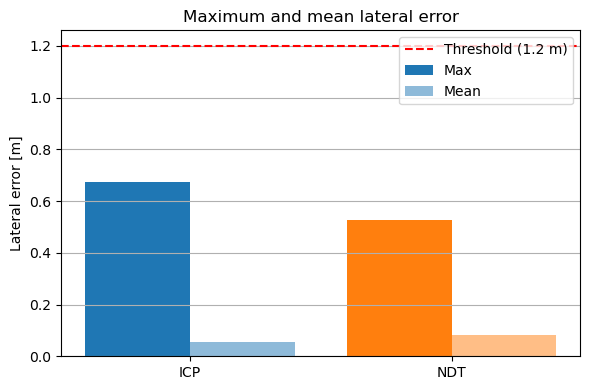

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["ICP", "NDT"]
maxes = [icp_lat_perp.max(), ndt_lat_perp.max()]
means = [icp_lat_perp.mean(), ndt_lat_perp.mean()]
x = np.arange(len(labels))
ax.bar(x - 0.2, maxes, width=0.4, label="Max", color=["C0", "C1"])
ax.bar(x + 0.2, means, width=0.4, label="Mean", color=["C0", "C1"], alpha=0.5)
ax.axhline(1.2, color="r", linestyle="--", label="Threshold (1.2 m)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Lateral error [m]")
ax.set_title("Maximum and mean lateral error")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

### Computation time

NDT is the clear winner on speed: ~242 ms per frame on average vs ~804 ms
for ICP, a roughly 3.3x speedup. The gap is even larger in the worst case
(NDT max ~680 ms vs ICP max ~6.8 s) because ICP occasionally needs many
iterations of KD-tree queries to converge on tight turns, while NDT's bounded
line search keeps every frame within a narrow band.

The reason is structural. ICP's per-iteration cost is dominated by the
KD-tree nearest-neighbour search performed for every scan point against a
local map of tens of thousands of points. NDT pays a one-off cost to build
the grid (very fast, since the grid only ends up with a few hundred
populated cells) and then runs a small number of fully vectorized Newton
iterations per frame, each of which only does an `O(N)` cell lookup and a
3x3 linear solve.

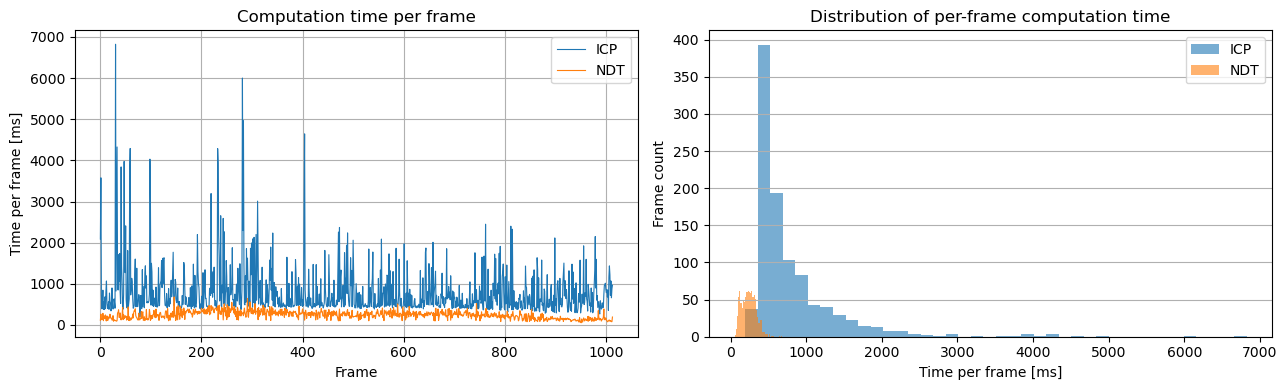

ICP  -- mean:  803.6 ms | median:  586.8 ms | max: 6823.4 ms | total:  814.8 s
NDT  -- mean:  242.4 ms | median:  240.3 ms | max:  681.5 ms | total:  245.8 s


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(icp_times * 1000, label="ICP", linewidth=0.8, color="C0")
axes[0].plot(ndt_times * 1000, label="NDT", linewidth=0.8, color="C1")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Time per frame [ms]")
axes[0].set_title("Computation time per frame")
axes[0].legend()
axes[0].grid(True)

axes[1].hist(icp_times * 1000, bins=40, alpha=0.6, label="ICP", color="C0")
axes[1].hist(ndt_times * 1000, bins=40, alpha=0.6, label="NDT", color="C1")
axes[1].set_xlabel("Time per frame [ms]")
axes[1].set_ylabel("Frame count")
axes[1].set_title("Distribution of per-frame computation time")
axes[1].legend()
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print(f"ICP  -- mean: {icp_times.mean()*1000:6.1f} ms | median: {np.median(icp_times)*1000:6.1f} ms | max: {icp_times.max()*1000:6.1f} ms | total: {icp_times.sum():6.1f} s")
print(f"NDT  -- mean: {ndt_times.mean()*1000:6.1f} ms | median: {np.median(ndt_times)*1000:6.1f} ms | max: {ndt_times.max()*1000:6.1f} ms | total: {ndt_times.sum():6.1f} s")

### Complexity

The two algorithms have very different costs per frame. Let N be the number of scan points after downsampling, M be the number of map (or local-map) points, K be the number of populated NDT cells, and T be the number of inner iterations per frame.

**ICP, step by step:** Before each frame, you voxel-downsample the scan in O(N) and build a KD-tree over the local map in O(M log M). Each inner iteration queries that KD-tree once per scan point, costing O(N log M), and does an SVD on a tiny 3x3 matrix, which is O(1). So the total per-frame cost is O(M log M + T · N log M).

**NDT, step by step:** Before each frame, you only voxel-downsample the scan in O(N). Each inner iteration looks up which cell every scan point falls into, costing O(N), and solves a small 3x3 Newton step, also O(1). That gives a per-frame cost of O(N + T · N). There is also a one-time setup cost to build the NDT grid: O(M) for sorting all the map points into cells, plus O(K) to fit a covariance to each occupied cell.

**Summary:** ICP spends most of its time running KD-tree nearest-neighbour queries over and over against a local map that can have tens of thousands of points - this dominates everything else. NDT avoids nearest-neighbour search altogether: it just does an O(N) cell lookup against a few hundred Gaussians and then a small fixed amount of linear algebra per Newton step. The line search inside each Newton iteration can still evaluate the score up to 50 times, which is where most of NDT's compute goes, but it never approaches the cost of ICP's repeated KD-tree queries. End result: NDT runs roughly 3.3x faster per frame in this implementation.

### Summary

- Both algorithms satisfy the criteria (max lateral error below 1.2 m, total distance above 170 m).
- **NDT has the lower worst-case lateral error** (0.53 m vs 0.67 m), while **ICP has the lower mean and median lateral error** (mean 0.06 m vs 0.08 m). In practice both should be well inside the 1.2 m so accuracy is essentially a tie.
- **NDT is ~3x faster per frame** on average (242 ms vs 804 ms) and has a ~10x tighter worst-case tail. ICP's KD-tree queries dominate its runtime, NDT replaces them with a constant-time cell lookup plus a few Newton iterations.
- NDT also represents the map far more compactly (a few hundred Gaussians vs ~100k map points), which would scale better to larger maps.
- Overall, in this scene NDT is both the more accurate (worst case) and the faster choice. ICP only wins on the average-case error, by a margin that is well below the assignment threshold.